In [1]:
"""
Frozen Dessert Production Forecasting with LSTM (TensorFlow/Keras)
------------------------------------------------------------------

This notebook trains an LSTM model to forecast monthly ice cream and frozen dessert production
using historical industrial production index data.

Covers:
- Data loading and cleaning
- Train/test split by date
- MinMax scaling
- Sequence generation
- LSTM model training
- Loss visualization
"""


'\nFrozen Dessert Production Forecasting with LSTM (TensorFlow/Keras)\n------------------------------------------------------------------\n\nThis notebook trains an LSTM model to forecast monthly ice cream and frozen dessert production\nusing historical industrial production index data.\n\nCovers:\n- Data loading and cleaning\n- Train/test split by date\n- MinMax scaling\n- Sequence generation\n- LSTM model training\n- Loss visualization\n'

In [2]:
# Basic Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Sklearn Utilities
from sklearn.preprocessing import MinMaxScaler

# TensorFlow GPU/CPU Config

# Enable memory growth for GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

# Configure threading
tf.config.threading.set_intra_op_parallelism_threads(32)
tf.config.threading.set_inter_op_parallelism_threads(32)


2025-04-26 07:00:40.480981: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-26 07:00:40.488881: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745676040.498237 1624868 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745676040.501104 1624868 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745676040.508784 1624868 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

GPU memory growth enabled


In [3]:

DATA_PATH = '/mnt/mls/data/udemy/Frozen_Dessert_Production.csv'

# Read data
df = pd.read_csv(DATA_PATH)

# Rename columns
df.columns = ['date', 'production']

# Convert 'date' to datetime
df['date'] = pd.to_datetime(df['date'])


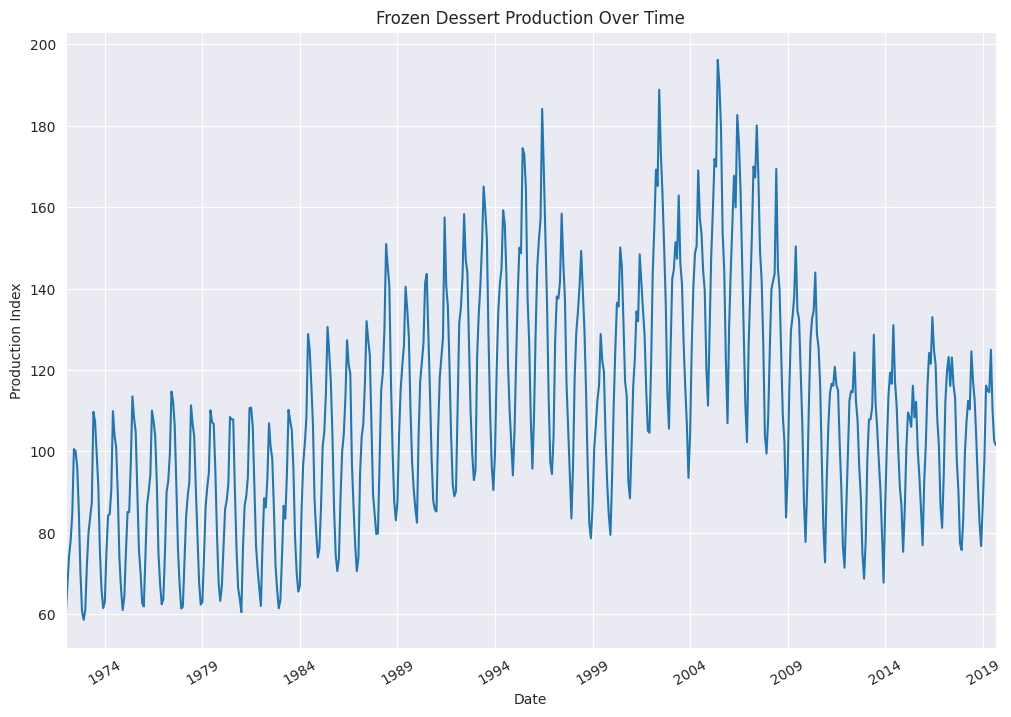

In [4]:

# Plot time series
fig = plt.figure(figsize=(12, 8))
df.set_index('date')['production'].plot()
plt.title('Frozen Dessert Production Over Time')
plt.xlabel('Date')
plt.ylabel('Production Index')
plt.xticks(rotation=30)
plt.show()


In [5]:

# Use last 24 months for test set
cutoff_date = df['date'].max() - pd.DateOffset(months=24)

train_data = df[df['date'] < cutoff_date].copy()
test_data = df[df['date'] >= cutoff_date].copy()

train_data.set_index('date', inplace=True)
test_data.set_index('date', inplace=True)


In [6]:

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data[['production']])
test_scaled = scaler.transform(test_data[['production']])


In [7]:

length = 3  # Looking at past 3 months
batch_size = 1

train_generator = TimeseriesGenerator(train_scaled, train_scaled, length=length, batch_size=batch_size)
validation_generator = TimeseriesGenerator(test_scaled, test_scaled, length=length, batch_size=batch_size)


In [8]:

model = Sequential([
    LSTM(100, activation='relu', input_shape=(length, 1), return_sequences=True),
    LSTM(50, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')


I0000 00:00:1745676042.073775 1624868 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1087 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:01:00.0, compute capability: 8.6
/mnt/mls/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, verbose=1)


In [10]:

history = model.fit(
    train_generator,
    epochs=100,
    validation_data=validation_generator,
    callbacks=[early_stopping, lr_scheduler]
)


Epoch 1/100


/mnt/mls/venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1745676043.981567 1625058 service.cc:152] XLA service 0xc80ea10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745676043.981583 1625058 service.cc:160]   StreamExecutor device (0): NVIDIA RTX A5000, Compute Capability 8.6
2025-04-26 07:00:44.017386: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1745676044.189439 1625058 cuda_dnn.cc:529] Loaded cuDNN version 90800


158/545 ━━━━━━━━━━━━━━━━━━━━ 0s 966us/step - loss: 0.0803

I0000 00:00:1745676044.783686 1625058 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


545/545 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0498 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 2/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 1s 970us/step - loss: 0.0224 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 3/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0148 - val_loss: 0.0096 - learning_rate: 0.0010
Epoch 4/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0124 - val_loss: 0.0039 - learning_rate: 0.0010
Epoch 5/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 1s 922us/step - loss: 0.0106 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 6/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 1s 940us/step - loss: 0.0088 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 7/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 1s 931us/step - loss: 0.0096 - val_loss: 0.0038 - learning_rate: 0.0010
Epoch 8/100
545/545 ━━━━━━━━━━━━━━━━━━━━ 1s 966us/step - loss: 0.0098 - val_loss: 0.0039 - learning_rate: 0.0010
Epoch 9/100
525/545 ━━━━━━━━━━━━━━━━━━━━ 0s 867us/step - loss: 0.0090
Epoch 9: ReduceLROnPlateau reducing learning

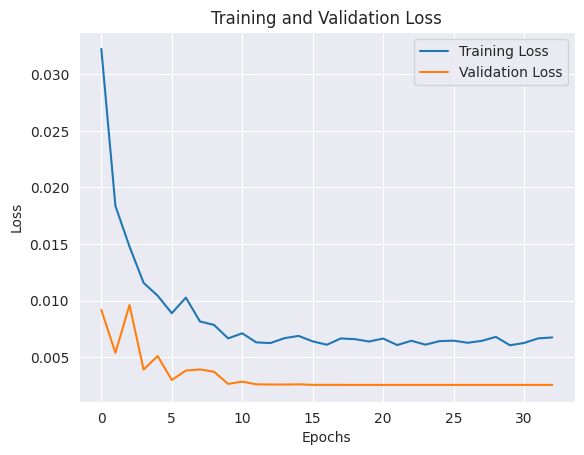

In [11]:

train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()
